In [22]:
# statistical testing 
from scipy.stats import fisher_exact
from scipy.stats import mannwhitneyu

# modules for data processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data processing for both control and 
df_CONTROL = pd.read_excel("RawData.xlsx", sheet_name="Control ")
df_EXPERIMENT = pd.read_excel("RawData.xlsx", sheet_name="Experiment")

In [5]:
# toy code
contingency_table = [[10, 5], [3, 12]]

# Perform Fisher's exact test (two-sided)
odds_ratio, p_value = fisher_exact(contingency_table, alternative='two-sided')

# Print the results
print(f"Contingency Table: {contingency_table}")
print(f"Odds Ratio: {odds_ratio:.4f}")
print(f"P-value: {p_value:.4f}")

# Compare p-value to significance level (alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print("Conclusion: There is a statistically significant association between gender and political party preference.")
else:
    print("Conclusion: There is no statistically significant association between gender and political party preference.")


Contingency Table: [[10, 5], [3, 12]]
Odds Ratio: 8.0000
P-value: 0.0253
Conclusion: There is a statistically significant association between gender and political party preference.


In [9]:
# toy code
# Define two distinct data samples
data1 = np.array([31, 22, 39, 27, 35, 28, 34, 26, 23, 33])
data2 = np.array([26, 25, 30, 28, 29, 28, 27, 30, 27, 28])

# Perform the Mann-Whitney U test
# 'two-sided' is the recommended alternative hypothesis for general use
u_statistic, p_value = mannwhitneyu(data1, data2, alternative='two-sided')

# Print the test statistic and p-value
print(f"U-value: {u_statistic}")
print(f"p-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("The p-value is less than the significance level (0.05). We reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference between the two groups.")
else:
    print("The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference between the two groups.")

U-value: 60.0
p-value: 0.4699923731723571
The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the two groups.


N_Control:  28
N_Experiment: 40


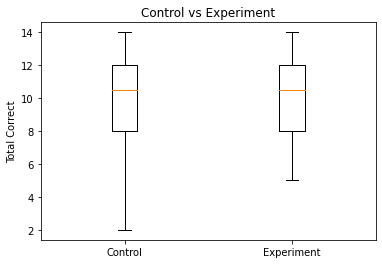

<Figure size 576x432 with 0 Axes>

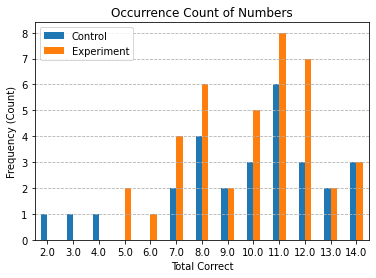

In [69]:
# mann-whitney u-test data representation
data_control = df_CONTROL.iloc[63]
data_experiment = df_EXPERIMENT.iloc[63]

# convert to a normal list and exclude the last four values because the data points are unclear and contains NaN
data_control_clean = pd.to_numeric(data_control[:-4], errors='coerce').dropna()
data_experiment_clean = pd.to_numeric(data_experiment[:-4], errors='coerce').dropna()

print("N_Control: ", len(data_control_clean))
print("N_Experiment:", len(data_experiment_clean))

# box plot
data_to_plot = [data_control_clean, data_experiment_clean]

plt.boxplot(data_to_plot, labels=['Control', 'Experiment'])
plt.title('Control vs Experiment')
plt.ylabel('Total Correct')

# bar graph
data_series_control = pd.Series(data_control_clean)
data_series_experiment = pd.Series(data_experiment_clean)

counts_control = data_series_control.value_counts().sort_index()
counts_experiment = data_series_experiment.value_counts().sort_index()

counts_df = pd.DataFrame({
    'Control': counts_control,
    'Experiment': counts_experiment
}).fillna(0)

plt.figure(figsize=(8, 6))
counts_df.plot(kind='bar')

plt.title('Occurrence Count of Numbers') # TODO: change the name
plt.xlabel('Total Correct')
plt.ylabel('Frequency (Count)')
plt.xticks(rotation=0) # Keeps the x-axis labels horizontal
plt.grid(axis='y', linestyle='--')

plt.show()

In [57]:
# mann-whitney test using Q60 row

"""
Mann-Whitney Conditions:
 - Independent observations
 - Two independent groups
 - Ordinal or continuous dependent variable
 - Similarity of distribution shape
 
Current Situ:
 - All the data points are independent of each other - there are different students in each group
 - The total correct is independent for groups Control and Experiment 
 - Total correct are rankable(why?)
 - The shape of the distributions of both Control and Experiment total correct are similar 
   -> test of median difference
 (NOTE - if it were not similar, it would have meant that it tests general distribution differences)
"""

data1 = np.array(data_control_clean)
data2 = np.array(data_experiment_clean)

"""
Null Hypothesis: The distribution of the control(PowerPoint) and experiment(GLE) total correct is the same

Alternative Hypothesis: The distribution of the control(PowerPoint) is tends to less value compared to the 
                        experiment(GLE) total correct distribution
"""

u_statistic, p_value = mannwhitneyu(data1, data2, alternative='less')
print(f"U-value: {u_statistic}")
print(f"p-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("The p-value is less than the significance level (0.05). We reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference between the two groups.")
else:
    print("The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference between the two groups.")

"""
Because the p-value (0.485) is greater than 0.05, we fail to reject the null hypothesis.
There is no significant evidence to conclude that the control (PowerPoint) group has lower 
median correct scores than the experimental (GLE) group. Applicable to only this sample.

--> the overall median performance does not have significant difference between the PowerPoint and GLE for groups
    similar to the study essentially.(testing does not confirm)
"""

U-value: 556.5
p-value: 0.48495123083071323
The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the two groups.


'\nBecause the p-value (0.485) is greater than 0.05, we fail to reject the null hypothesis.\nThere is no significant evidence to conclude that the control (PowerPoint) group has lower \ntotal correct scores than the experimental (GLE) group.\n'

In [79]:
# fisher's exact test data representation
"""
Mosaic plot may be used
"""

# data processing
# n_correct
dt_control_NC = df_CONTROL.iloc[20]
dt_experiment_NC = df_EXPERIMENT.iloc[20]

dt_control_NC_clean = pd.to_numeric(dt_control_NC[:-4], errors='coerce').dropna()
dt_experiment_NC_clean = pd.to_numeric(dt_experiment_NC[:-4], errors='coerce').dropna()

print("N_Control, n_correct: ", len(dt_control_NC_clean))
print("N_Experiment, n_correct:", len(dt_experiment_NC_clean))

#...

# function to count how many occurence of a number appears
def count_num(num, list):
    count = 0
    for i in list:
        if i == num:
            count +=1
    
    return count

# conclusion functions
def conclusion(p_value, alpha = 0.05):
    if p_value < alpha:
        print("The p-value is less than the significance level (0.05). We reject the null hypothesis.")
        print("Conclusion: There is a statistically significant difference between the two groups.")
    else:
        print("The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.")
        print("Conclusion: There is no statistically significant difference between the two groups.")


N_Control, n_correct:  28
N_Experiment, n_correct: 40


In [84]:
# fisher's exact test 
"""
Fisher's Exact Test Conditions:
 - Categorical data(counts only)
 - Two categorical data
 - 2 x 2 contingency table
 - Independence of Observations
 - Small sample or low expected counts(expected counts are below 5)
 
Current Situ:
 - All data are category
 - The categorical data collected is if the selected answer correct or incorrect
 - See below
 - The observations for each data are independent from each other
 - See each case
"""

# general structure of contingency table
"""
Structure
            | Incorrect(0) |  Correct(1)  |    
Control     |              |              |
Experiment  |              |              |
"""

"""
            | Incorrect(0) |  Correct(1)  |    
Control     |     4.9      |    23.01     |
Experiment  |     7.1      |    23.94     |
Small sample condition is met
"""
# n_correct analysis
contingency_table_NC = [[count_num(0, dt_control_NC_clean), count_num(1, dt_control_NC_clean)], [count_num(0, dt_experiment_NC_clean), count_num(1, dt_experiment_NC_clean)]]

"""
Null hypothesis: There are no association between the control and experiment n_correct(i.e. independent).

Alternative Hypothesis: There is an assoication between the control and experiment total n_correct

* Experiment(GLE) should increase of accuracy for the questions
""" 
odds_ratio_NC, p_value_NC = fisher_exact(contingency_table_NC, alternative='greater')

print(f"Contingency Table_NC: {contingency_table_NC}")
print(f"Odds Ratio_NC: {odds_ratio_NC}")
print(f"P-value_NC: {p_value_NC}")

conclusion(p_value_NC)

"""
Because the p-value (0.157) is greater than 0.05, we fail to reject the null hypothesis.
There is no significant evidence to conclude that the there is an association between the control and experiment answers
the question correctly.
"""

Contingency Table_NC: [[7, 21], [5, 35]]
Odds Ratio_NC: 2.3333333333333335
P-value_NC: 0.15689632998119343
The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the two groups.
